# EM casing response dipole source

In [1]:
import numpy as np
import os
import scipy.sparse as sp
import pandas as pd
from scipy.constants import mu_0
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, LinearSegmentedColormap, Normalize, SymLogNorm
from matplotlib import cm as colormap
import time
from string import ascii_lowercase
import pickle
from multiprocessing import Pool

# SimPEG, discretize/
import discretize
from discretize import utils
from simpeg.electromagnetics import frequency_domain as fdem
from simpeg.electromagnetics.static import resistivity as dc
from simpeg.electromagnetics.utils import line_through_faces
from simpeg import(
    maps, Report, data,
    data_misfit,
    inverse_problem,
    regularization,
    optimization,
    directives,
    inversion,
    utils
)
from pymatsolver import Pardiso

from utils import pad_for_casing_and_data

In [2]:
from matplotlib import rcParams
rcParams["font.size"] = 16

In [3]:
directory_path = "/t40array/lheagy/casing-upscaling"

In [4]:
def ensure_directory_exists(directory_path):
    if not os.path.exists(directory_path):
        os.makedirs(directory_path)
        print(f"Directory '{directory_path}' created.")
    else:
        print(f"Directory '{directory_path}' already exists.")

# Example usage
ensure_directory_exists(directory_path)

Directory '/t40array/lheagy/casing-upscaling' already exists.


In [5]:
save_figures = False
fig_dir_high = "figures"
fig_dir_low = "low-rez-figures"

dpi_high=400
dpi_low=150

## Simulation parameters

In [229]:
# # conductivities
sigma_air = 1e-4
sigma_back = np.r_[1e-1]
casing_l = 500
sigma_casing = 5e6
mur_casing = np.r_[1, 2, 10, 25, 50, 100, 150, 200]

# # casing geometry
casing_b = 5e-2
# casing_b_test = np.r_[5e-2, 1e-1, 2e-1]
casing_b_test = np.r_[2.5e-2, 5e-2, 1e-1]
casing_t = 1e-2 #np.r_[5e-3, 7.5e-3, 10e-3, 12.5e-3, 15e-3, 20e-3]
# casing_t_test = np.r_[1e-2, 2e-2, 4e-2]
casing_t_test = np.r_[0.5e-2, 1e-2, 2e-2]
casing_a = casing_b - casing_t

In [230]:
src_dz = 10
src_z = -515 #np.r_[-100, -250, -400, -495, -500, -550, -600]

In [231]:
# generate a mesh
hx = pad_for_casing_and_data(
   casing_outer_radius = np.max(casing_b_test),
    csx1 = casing_t/8, 
    csx2 = 25, 
    pfx1 = 1.3,
    pfx2 = 1.5, 
    domain_x = 600, 
    npadx = 10
)

pfz = 1.3
npad_z = 28
csz = 0.5
n_core_extra = 10
ncore_z = int(np.max(np.r_[np.abs(casing_l), np.abs(src_z)]) / csz) + n_core_extra
hz = discretize.utils.unpack_widths(
    [(csz, npad_z, -pfz), (csz, ncore_z), (csz, npad_z, pfz)]
)

<Axes: xlabel='x', ylabel='z'>

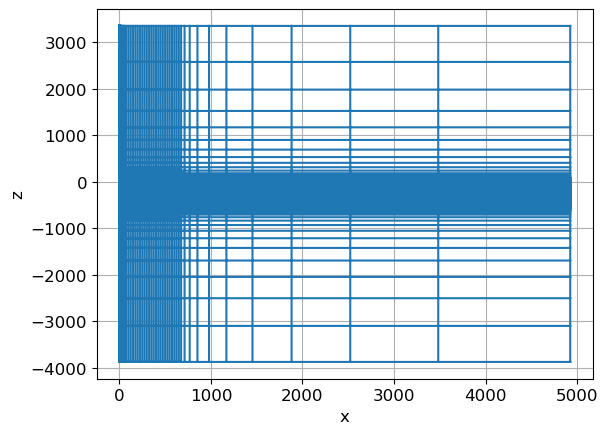

In [232]:
mesh = discretize.CylindricalMesh(
    [hx, np.r_[2*np.pi], hz], origin=np.r_[0, 0, -np.sum(hz[:npad_z + int(ncore_z)])],
)

fig, ax = plt.subplots(1, 1)
mesh.plot_grid(ax=ax)
# ax.set_xlim([0, 5])
# ax.set_ylim(-50, 10)

In [233]:
mesh.n_cells

167688

In [234]:
def get_physical_property_model(mesh, casing_a, casing_b, casing_l, sigma_back, sigma_casing, sigma_air=1e-4, mur_casing=1):

    model = np.ones(mesh.n_cells)*sigma_air
    model[mesh.cell_centers[:, 2] < 0] = sigma_back

    mur = np.ones(mesh.n_cells)

    inds_casing_x = (
        (mesh.cell_centers[:, 0] > casing_a) & 
        (mesh.cell_centers[:, 0] < casing_b)
    )
    inds_casing_z = (
        (mesh.cell_centers[:, 2] < 0) &
        (mesh.cell_centers[:, 2] > -casing_l)
    )
    inds_casing = inds_casing_x & inds_casing_z

    model[inds_casing] = sigma_casing
    mur[inds_casing] = mur_casing

    return model, mur

    

In [235]:
sigma_back

array([0.1])

In [236]:
models_t = {}
models_b = {}

def get_models_over_mu(casing_a, casing_b): 
    models = {}
    for mur in mur_casing:
        key = f"casing_sig{sigma_casing:1.0e}_mur{mur:1.0f}"
        sig_model, mur_model = get_physical_property_model(mesh, casing_a, casing_b, casing_l, sigma_back[0], sigma_casing, mur_casing=mur)
        models[key] = {
            "sigma": sig_model, 
            "mur": mur_model
        }
    return models

for t in casing_t_test: 
    models_t[t] = get_models_over_mu(casing_b - t, casing_b)

for b in casing_b_test: 
    models_b[b] = get_models_over_mu(b-casing_t, b)

In [237]:
models_t.keys(), models_b.keys()

(dict_keys([0.005, 0.01, 0.02]), dict_keys([0.025, 0.05, 0.1]))

In [238]:
def plot_casing(model, xlim=None, zlim=None, vmin=None, vmax=None, ax=None, cb_label=None, logscale=True, show_cb=False): 
    if ax is None: 
        fig, ax = plt.subplots(1, 1)
    if logscale is True: 
        pcolor_opts={"norm":LogNorm(vmin=vmin, vmax=vmax), "cmap":"Spectral_r"}
    else: 
        pcolor_opts={"norm":Normalize(vmin=vmin, vmax=vmax), "cmap":"Spectral_r"}
    out = mesh.plot_image(
        model, pcolor_opts=pcolor_opts, ax=ax, mirror=True
    )

    if show_cb is True: 
        cb = plt.colorbar(out[-1], shrink=0.5)
        cb.set_label(cb_label)

    if xlim is not None: 
        ax.set_xlim(xlim)
    if zlim is not None: 
        ax.set_ylim(zlim)

    ax.set_xlabel("x (m)")
    ax.set_ylabel("z (m)")
    return ax, out

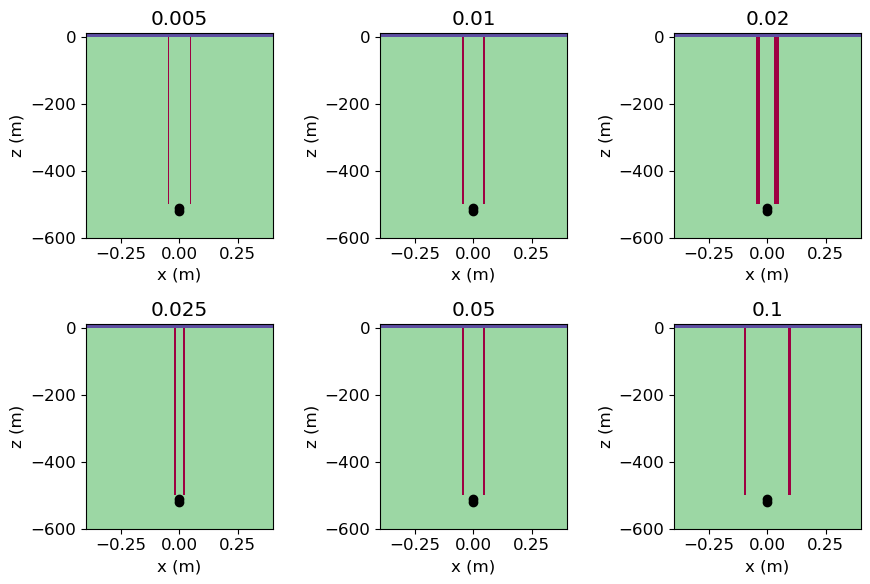

In [239]:
fig, ax = plt.subplots(2, 3, figsize=(9, 6))

xlim = 0.4*np.r_[-1, 1]
zlim = np.r_[-600, 10]
vmin = sigma_air
vmax = sigma_casing

for j, models in enumerate([models_t, models_b]):
    for i, key in enumerate(models.keys()):
        plotme = list(models[key].values())[0]
        plot_casing(plotme["sigma"], xlim=xlim, zlim=zlim, vmin=vmin, vmax=vmax, ax=ax[j, i])
        ax[j, i].set_title(key)
        ax[j, i].plot(np.r_[0, 0], src_z + src_dz/2 * np.r_[-1, 1], "-ok")

plt.tight_layout()
# for loc in src_z:
#     ax.plot(np.r_[0, 0], loc + src_dz/2*np.r_[-1, 1], "-k", lw=4, alpha=0.5)

## set up the simulations

In [240]:
frequencies = 10**np.linspace(-1, 4, 36)[:1]
frequencies

array([0.1])

In [241]:
src_list = []
src_locations = np.array([
    [0, 0, src_z+src_dz/2.],
    [0, 0, src_z-src_dz/2.]
])
for f in frequencies: 
    src = fdem.sources.LineCurrent([], location=src_locations, frequency=f)
    src_list.append(src)

wires = maps.Wires(("sigma", mesh.n_cells), ("mur", mesh.n_cells))
permeability_map = maps.MuRelative(mesh)

survey = fdem.Survey(src_list)

sim = fdem.simulation.Simulation3DMagneticField(
    mesh=mesh, sigmaMap=wires.sigma, muMap=permeability_map * wires.mur,
    survey=survey, solver=Pardiso, #mu=mur * mu_0
#     verbose=True
)

In [242]:
def run_simulation(model):
    
    # filename = os.path.sep.join([directory_path, key])

    t = time.time()
    print(f"starting {model['sigma'].max():1.1e}, {model['mur'].max():1.1f}...")
    fields = sim.fields(np.r_[model["sigma"], model["mur"]])
    print(f" ... done. {time.time()-t:1.2e} \n")
    
    # np.save(filename, fields[:, "hSolution"])

    return fields

In [243]:
def get_fields_for_models(models): 
    fields = {}
    for key_i, model_i in models.items():
        fields_tmp = {}
        for key, val in model_i.items():
            fields_tmp[key] = run_simulation(val)
        fields[key_i] = fields_tmp
    return fields

In [244]:
fields_t = get_fields_for_models(models_t)
fields_b = get_fields_for_models(models_b)

starting 5.0e+06, 1.0...
 ... done. 1.33e+00 

starting 5.0e+06, 2.0...
 ... done. 7.15e-01 

starting 5.0e+06, 10.0...
 ... done. 6.24e-01 

starting 5.0e+06, 25.0...
 ... done. 6.06e-01 

starting 5.0e+06, 50.0...
 ... done. 6.24e-01 

starting 5.0e+06, 100.0...
 ... done. 6.13e-01 

starting 5.0e+06, 150.0...
 ... done. 6.03e-01 

starting 5.0e+06, 200.0...
 ... done. 5.93e-01 

starting 5.0e+06, 1.0...
 ... done. 7.13e-01 

starting 5.0e+06, 2.0...
 ... done. 5.81e-01 

starting 5.0e+06, 10.0...
 ... done. 5.78e-01 

starting 5.0e+06, 25.0...
 ... done. 5.52e-01 

starting 5.0e+06, 50.0...
 ... done. 5.45e-01 

starting 5.0e+06, 100.0...
 ... done. 5.85e-01 

starting 5.0e+06, 150.0...
 ... done. 5.40e-01 

starting 5.0e+06, 200.0...
 ... done. 5.69e-01 

starting 5.0e+06, 1.0...
 ... done. 5.92e-01 

starting 5.0e+06, 2.0...
 ... done. 5.62e-01 

starting 5.0e+06, 10.0...
 ... done. 5.62e-01 

starting 5.0e+06, 25.0...
 ... done. 5.43e-01 

starting 5.0e+06, 50.0...
 ... done. 5.6

In [43]:
fields_t
fields_b

{0.05: {'casing_sig5e+06_mur1': <simpeg.electromagnetics.frequency_domain.fields.Fields3DMagneticField at 0x7f1e02b09f10>,
  'casing_sig5e+06_mur2': <simpeg.electromagnetics.frequency_domain.fields.Fields3DMagneticField at 0x7f1e0d8fcd10>,
  'casing_sig5e+06_mur10': <simpeg.electromagnetics.frequency_domain.fields.Fields3DMagneticField at 0x7f1e02558ed0>,
  'casing_sig5e+06_mur25': <simpeg.electromagnetics.frequency_domain.fields.Fields3DMagneticField at 0x7f1e02d09250>,
  'casing_sig5e+06_mur50': <simpeg.electromagnetics.frequency_domain.fields.Fields3DMagneticField at 0x7f1e02d11990>,
  'casing_sig5e+06_mur100': <simpeg.electromagnetics.frequency_domain.fields.Fields3DMagneticField at 0x7f1e0dad3190>,
  'casing_sig5e+06_mur150': <simpeg.electromagnetics.frequency_domain.fields.Fields3DMagneticField at 0x7f1e02bfbc90>,
  'casing_sig5e+06_mur200': <simpeg.electromagnetics.frequency_domain.fields.Fields3DMagneticField at 0x7f1e02969c50>},
 0.1: {'casing_sig5e+06_mur1': <simpeg.electroma

In [245]:
model_keys = list(fields_t[casing_t_test[0]].keys())
model_keys

['casing_sig5e+06_mur1',
 'casing_sig5e+06_mur2',
 'casing_sig5e+06_mur10',
 'casing_sig5e+06_mur25',
 'casing_sig5e+06_mur50',
 'casing_sig5e+06_mur100',
 'casing_sig5e+06_mur150',
 'casing_sig5e+06_mur200']

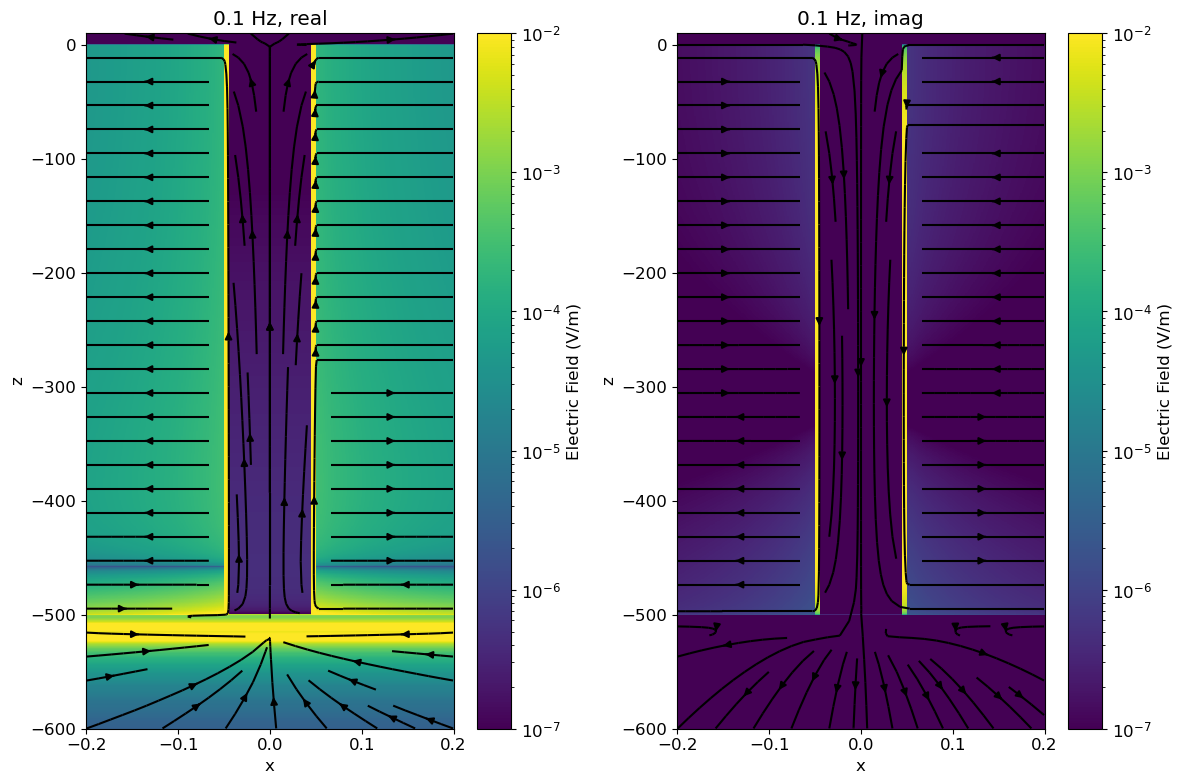

In [246]:
fig, ax = plt.subplots(1, 2, figsize=(12, 8))

model_key = model_keys[0]
key_t = casing_t_test[0]
freq_ind = 0
xlim = 0.2*np.r_[-1, 1]
zlim = np.r_[-600, 10]

field_plot = (mesh.average_face_to_cell_vector * fields_t[key_t][model_key][fields_t[key_t][model_key].simulation.survey.source_list[freq_ind], "j"])

for i, component in enumerate(["real", "imag"]): 
    out = mesh.plot_image(
        getattr(field_plot, component), "CCv", view="vec", 
        range_x = xlim, range_y = zlim,
        # sample_grid = np.r_[10, 10],
        mirror=True, #mirror_data=field_mirror,
        ax=ax[i], 
        pcolor_opts={"norm":LogNorm(vmin=1e-7, vmax=1e-2)}
    )
    # ax[i].plot(rx_ex_re.locations[:, 0], rx_ex_re.locations[:, 2], "w.", ms=1)
    cb = plt.colorbar(out[0], ax=ax[i])
    cb.set_label("Electric Field (V/m)")
    # ax[i].set_aspect(1)
    ax[i].set_title(f"{frequencies[freq_ind]} Hz, {component}")
plt.tight_layout()

In [247]:
# def load_fields(name, conductivity, mur):
#     solution = np.load(f"{directory}/fields_{name}.npy")
#     sim = generate_simulation(mur)
#     sim.model = conductivity
#     f = sim.fieldsPair(sim)
#     f[:, sim._solutionType] = solution
#     return f

# choose models to focus on

In [248]:
len(frequencies)

1

In [249]:
# casing_t_inv = np.r_[5e-3]
# mur_inv = np.r_[1, 50, 100, 150, 200]
# freq_inds_inv = np.arange(0, 31, 1)
# src_ind_inv = 5

# inv_keys = []
# for t in casing_t_inv:
#     for mur in mur_inv:
#         inv_keys.append(f"casing_{mur}_{t:1.2e}")
# inv_keys

In [250]:
# frequencies[freq_inds_inv]

In [251]:
# fields = {}
# for key in inv_keys:
#     # if key not in fields.keys():
#     fields[key] = load_fields(key, models[key]["sigma"], models[key]["mur"])

In [252]:
rcParams["font.size"] = 12

In [253]:
def skin_depth(f, sigma, mur):
    return np.sqrt(2/(2*np.pi*f*sigma*mur*mu_0))

In [254]:
rx_x = np.linspace(25, 500, 20)
rx_z = -np.linspace(0, 600, 25) - csz/2
rx_z

array([-2.5000e-01, -2.5250e+01, -5.0250e+01, -7.5250e+01, -1.0025e+02,
       -1.2525e+02, -1.5025e+02, -1.7525e+02, -2.0025e+02, -2.2525e+02,
       -2.5025e+02, -2.7525e+02, -3.0025e+02, -3.2525e+02, -3.5025e+02,
       -3.7525e+02, -4.0025e+02, -4.2525e+02, -4.5025e+02, -4.7525e+02,
       -5.0025e+02, -5.2525e+02, -5.5025e+02, -5.7525e+02, -6.0025e+02])

In [255]:
def create_receivers():
    rx_ex_re = fdem.receivers.PointElectricField(
        locations=discretize.utils.ndgrid(rx_x, np.r_[0], rx_z),
        orientation="x",
        component="real",
    )
    rx_ex_im = fdem.receivers.PointElectricField(
        locations=discretize.utils.ndgrid(rx_x, np.r_[0], rx_z),
        orientation="x",
        component="imag",
    )
    rx_ez_re = fdem.receivers.PointElectricField(
        locations=discretize.utils.ndgrid(rx_x, np.r_[0], rx_z),
        orientation="z",
        component="real",
    )
    rx_ez_im = fdem.receivers.PointElectricField(
        locations=discretize.utils.ndgrid(rx_x, np.r_[0], rx_z),
        orientation="z",
        component="imag",
    )
    return rx_ex_re, rx_ex_im, rx_ez_re, rx_ez_im

In [256]:
rx_ex_re, rx_ex_im, rx_ez_re, rx_ez_im = create_receivers()
Px = rx_ex_re.getP(mesh, "Fx")
Pz = rx_ez_re.getP(mesh, "Fz")

In [257]:
frequencies

array([0.1])

In [258]:
range(len(frequencies))

range(0, 1)

In [259]:
# get data_vectors

def get_dobs(fields): 
    dobs_dict = {}
    
    for k in fields.keys():
        tmp_dict = {}
        for si in range(len(frequencies)):
            src = sim.survey.source_list[si]
            e = fields[k][src, "e"]
            edatax = (Px * e).squeeze()
            edataz = (Pz * e).squeeze()
            tmp_dict[frequencies[si]] = {
                "real_x": edatax.real,
                "imag_x": edatax.imag,
                "real_z": edataz.real,
                "imag_z": edataz.imag
            }
        dobs_dict[k] = tmp_dict
    return dobs_dict

In [260]:
dobs_dict_t = {}
for key, val in fields_t.items():
    dobs_dict_t[key] = get_dobs(val)

In [261]:
dobs_dict_b = {}
for key, val in fields_b.items():
    dobs_dict_b[key] = get_dobs(val)

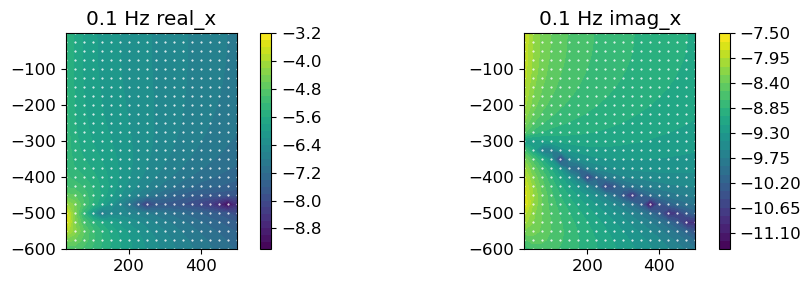

In [262]:
fig, ax = plt.subplots(len(frequencies), 2, figsize=(10, len(frequencies)*3), sharex=True)

key_ind = 0
model_key = model_keys[0]
key_t = casing_t_test[1]

ax=np.atleast_2d(ax)

for i, freq in enumerate(frequencies): 
    # ax.plot(rx_x, dobs_dict[key][freq]["real"].reshape((len(rx_x), len(rx_z)), order="F"), "o" );
    for j, component in enumerate(["real_x", "imag_x"]): 
        plt.colorbar(
            ax[i, j].contourf(
                rx_x, rx_z, np.log10(np.abs(dobs_dict_t[key_t][model_key][frequencies[0]][component].reshape((len(rx_x), len(rx_z)), order="F").T)), 30,
                # vmin=-7, vmax=-2
                # norm=LogNorm()
            ), ax=ax[i, j]
        )
        
        ax[i, j].plot(rx_ex_re.locations[:, 0], rx_ex_re.locations[:, 2], "w.", ms=1)
        ax[i, j].set_aspect(1)
        ax[i, j].set_title(f"{freq} Hz {component}")

plt.tight_layout()


In [263]:
def get_amplitude_phase(real, imag):
    # real = f.real
    # imag = f.imag
    amplitude = np.sqrt(real**2 + imag**2)
    phase = 180/np.pi*np.arctan2(imag, real)
    return amplitude, phase

In [264]:
# fig, ax = plt.subplots(len(frequencies), 2, figsize=(10, len(frequencies)*3), sharex=True)

# key_ind = 0
# key = keys[key_ind]

# for i, freq in enumerate(frequencies): 
#     amp, phase = get_amplitude_phase(*(dobs_dict[key][freq][component].reshape((len(rx_x), len(rx_z)), order="F").T for component in ["real", "imag"]))
#     for j, plotme in enumerate([np.log10(np.abs(amp)), phase]): 
#         plt.colorbar(
#             ax[i, j].contourf(
#                 rx_x, rx_z, plotme, 30,
#                 # vmin=-7, vmax=-2
#                 # norm=LogNorm()
#                 cmap = "twilight" if j == 1 else "viridis"
#             ), ax=ax[i, j]
#         )
        
#         ax[i, j].plot(rx_e_re.locations[:, 0], rx_e_re.locations[:, 2], "w.", ms=1)
#         ax[i, j].set_aspect(1)
#         ax[i, j].set_title(f"{freq} Hz {'amplitude' if j==0 else 'phase'}")

# plt.tight_layout()


# set up mappings and simulation

In [265]:
def create_maps(model, casing_b):
    indsx = (mesh.cell_centers[:, 0] < casing_b)
    
    inds_interior = (
        indsx &
        (mesh.cell_centers[:, 2] <= 0) &
        (mesh.cell_centers[:, 2] >= -casing_l)
    )

    active_inds_sigma = maps.InjectActiveCells(
        mesh, indActive=inds_interior, 
        valInactive=np.log(model["sigma"][~inds_interior])
    )

    active_inds_mur = maps.InjectActiveCells(
        mesh, indActive=inds_interior, 
        valInactive=model["mur"][~inds_interior]
    )

    projection_sigma = maps.SurjectUnits(indices=[np.ones(inds_interior.sum(), dtype=bool)])
    projection_mu = maps.SurjectUnits(indices=[np.ones(inds_interior.sum(), dtype=bool)])

    exp_map = maps.ExpMap(mesh)
    mur_map = maps.MuRelative(mesh)

    sigma_map = exp_map * active_inds_sigma * projection_sigma
    mu_map = mur_map * active_inds_mur * projection_mu

    return sigma_map, mu_map

In [266]:
def create_survey(freq, components=["x", "z"]): 
    rx_ex_re, rx_ex_im, rx_ez_re, rx_ez_im = create_receivers()
    rx_list = []
    if "x" in components: 
        rx_list.append([rx_ex_re, rx_ex_im])
    if "z" in components: 
        rx_list.append([rx_ez_re, rx_ez_im])
    src = fdem.sources.LineCurrent(list(np.hstack(rx_list)), location=src_locations, frequency=freq)
    return fdem.Survey([src])

In [267]:
# create the simulation
def create_simulation(model, casing_b, survey, invert_mu=False):
    sigma_map, mu_map = create_maps(model, casing_b)

    if invert_mu is True: 
        wires = maps.Wires(("sigma", 1), ("mu", 1))
        sim = fdem.simulation.Simulation3DMagneticField(
            mesh, survey=survey, solver=Pardiso, 
            sigmaMap=sigma_map * wires.sigma,
            muMap=mu_map * wires.mu 
        )
    else: 
        sim = fdem.simulation.Simulation3DMagneticField(
            mesh, survey=survey, solver=Pardiso, 
            sigmaMap=sigma_map
        )
    return sim


In [268]:
from string import ascii_lowercase

# set up inversions

In [269]:
class SaveInversionProgress(directives.InversionDirective):
    """
    A custom directive to save items of interest during the course of an inversion
    """
    
    results_file = None
    
    def initialize(self):
        """
        This is called when we first start running an inversion
        """
        # initialize an empty dictionary for storing results 
        self.inversion_results = {
            "iteration":[],
            "phi_d":[],
            "dpred":[],
            "logsigma":[],
            "mur":[],
            "residual":[],
            "rms":[],
        }

    def endIter(self):
        """
        This is run at the end of every iteration. So here, we just append 
        the new values to our dictionary
        """
        
        # Save the data
        self.inversion_results["iteration"].append(self.opt.iter)
        self.inversion_results["phi_d"].append(self.invProb.phi_d)
        self.inversion_results["dpred"].append(self.invProb.dpred)
        self.inversion_results["logsigma"].append(self.invProb.model[0])
        self.inversion_results["mur"].append(self.invProb.model[1])

        dobs = self.invProb._dmisfit.objfcts[0].data.dobs
        
        self.inversion_results["residual"].append((dobs - self.invProb.dpred))
        self.inversion_results["rms"].append(np.sqrt(np.sum(self.inversion_results["residual"][-1]**2)/len(dobs)))
        
        # if self.results_file is not None: 
        #     with open(f"{self.results_file}", "wb") as fp:
        #         pickle.dump(self.inversion_results, fp)
        
        

In [270]:
def create_inversion(
    model, dobs_dict, casing_b, freq=frequencies[0], invert_mu=False, relative_error=None, noise_floor=None,
    maxIter=20, maxIterCG=50, maxIterLS=10, true_casing_inds=False, components=["x", "z"],
    chifact=0.5
):
    # create the simulation
    survey = create_survey(freq, components)

    receivers = []
    if "x" in components: 
        receivers.append(["real_x", "imag_x"])
    if "z" in components: 
        receivers.append(["real_z", "imag_z"])
    dobsvec = np.hstack([dobs_dict[rx] for rx in np.hstack(receivers)])
    dobs = data.Data(
        survey=survey, dobs=dobsvec, relative_error=relative_error, noise_floor=noise_floor
    )

    sim = create_simulation(model, casing_b, survey, invert_mu=invert_mu)
    dmis = data_misfit.L2DataMisfit(data=dobs, simulation=sim)

    if invert_mu is True: 
        reg = regularization.Smallness(mesh=discretize.TensorMesh([2]))
        opt = optimization.ProjectedGNCG(
            maxIter=maxIter, lower=np.r_[-np.inf, 0], upper=np.r_[np.log(100*sigma_casing), np.inf],
            maxIterCG=maxIterCG, maxIterLS=maxIterLS,
            # aggressive_stepping=True
            # tolF=1e-3, tolX=1e-3,
        )
    
    else: 
        reg = regularization.Smallness(mesh=discretize.TensorMesh([1]))
        opt = optimization.ProjectedGNCG(
            maxIter=maxIter, lower=np.r_[-np.inf], 
            maxIterCG=maxIterCG, maxIterLS=maxIterLS,
            # aggressive_stepping=True
            # tolF=1e-3, tolX=1e-3,
        )

    inv_prob = inverse_problem.BaseInvProblem(dmis, reg, opt, beta=0)

    # directives
    target_misfit = directives.TargetMisfit(chifact=chifact)
    
    # if true_casing_inds:
    #     filename_save = f"inv_{key}_{freq:1.0f}_true_casing.pkl"
    # else: 
    #     filename_save = f"inv_{key}_{freq:1.0f}.pkl"
    inversion_progress = SaveInversionProgress()
    
    # inversion 
    inv = inversion.BaseInversion(inv_prob, [target_misfit, inversion_progress])
    
    return inv

In [271]:
relative_error = 0.0
noise_floor = 1e-9

def create_inv_dict(model, dobs_dict, casing_b):
    inv_dict = {}
    for i, key in enumerate(model.keys()):
        chifact = 0.00001
        
        tmp = {}
        for freq in frequencies:
            
            tmp[freq] = create_inversion(
                    model[key], dobs_dict[key][freq], casing_b, 
                    invert_mu=True, relative_error=relative_error, noise_floor=noise_floor,
                    components=["x", "z"], chifact=chifact
                )
        inv_dict[key] = tmp
    return inv_dict

In [272]:
models_t.keys()

dict_keys([0.005, 0.01, 0.02])

In [273]:
dobs_dict_t.keys()

dict_keys([0.005, 0.01, 0.02])

In [274]:
inv_dict_t = {} 

for key in models_t.keys(): 
    inv_dict_t[key] = create_inv_dict(models_t[key], dobs_dict_t[key], casing_b) 


In [275]:
inv_dict_b = {} 

for i, key in enumerate(models_b.keys()): 
    inv_dict_b[key] = create_inv_dict(models_b[key], dobs_dict_b[key], casing_b_test[i]) 


In [276]:
# t = casing_t
# sigdc = sigma_casing * (1-(casing_b-t)**2/casing_b**2)
# starting_models = {
#     True: np.r_[np.log(sigstart), 1],
#     False: np.r_[np.log(sigstart)]
# }

In [277]:
# geometric_factor = casing_t / (2*casing_b) * (3 - casing_t / casing_b)

In [278]:
models_start_t = {
    t : {
        key: np.r_[np.log(sigma_casing * (1-(casing_b-t)**2/casing_b**2)), mur_casing[i]]
        for i, key in enumerate(models_t[t].keys())
    }
    for t in casing_t_test
}
# models_start_t

In [279]:
models_start_b = {
    b : {
        key: np.r_[np.log(sigma_casing * (1-(b-casing_t)**2/b**2)), mur_casing[i]]
        for i, key in enumerate(models_b[b].keys())
    }
    for b in casing_b_test
}
# models_start_b

In [280]:
def run_inversions(inv_dict, models_start):
    mrec_dict = {}
    for i, key in enumerate(inv_dict.keys()):
        tmp = {}
        for j, freq in enumerate(frequencies):
            print(f"\n\n------------------------ {key} : {freq} Hz -------------------------- \n")
            tmp[freq] = inv_dict[key][freq].run(models_start[key])
            print(f"recovered conductivity: {np.exp(inv_dict[key][freq].m[0]):1.2e}, recovered permeability: {inv_dict[key][freq].m[1]:1.2f} mu0 \n")
        mrec_dict[key] = tmp
    return mrec_dict

In [282]:
mrec_dict_t = {}

for t in casing_t_test:
    print(f"============================= {t} m ======================================")
    mrec_dict_t[t] = run_inversions(inv_dict_t[t], models_start_t[t])


============================= 0.005 m ======================================


------------------------ casing_sig5e+06_mur1 : 0.1 Hz -------------------------- 


                        simpeg.InvProblem is setting bfgsH0 to the inverse of the eval2Deriv.
                        ***Done using same Solver, and solver_opts as the Simulation3DMagneticField problem***
                        
model has any nan: 0
=============================== Projected GNCG ===============================
  #     beta     phi_d     phi_m       f      |proj(x-g)-x|  LS    Comment   
-----------------------------------------------------------------------------
x0 has any nan: 0
   0  0.00e+00  1.08e+03  0.00e+00  1.08e+03    1.52e+05      0              
   1  0.00e+00  9.56e+02  3.72e-01  9.56e+02    6.27e+00      0              
   2  0.00e+00  9.56e+02  3.72e-01  9.56e+02    6.27e+00      0              
   3  0.00e+00  9.56e+02  3.73e-01  9.56e+02    4.30e+01      0   Skip BFGS  
   4  0.00e+00  9.56

In [283]:
mrec_dict_b = {}

for b in casing_b_test:
    print(f"============================= {b} m ======================================")
    mrec_dict_b[b] = run_inversions(inv_dict_b[b], models_start_b[b])


============================= 0.025 m ======================================


------------------------ casing_sig5e+06_mur1 : 0.1 Hz -------------------------- 

simpeg.InvProblem will set Regularization.reference_model to m0.

                        simpeg.InvProblem is setting bfgsH0 to the inverse of the eval2Deriv.
                        ***Done using same Solver, and solver_opts as the Simulation3DMagneticField problem***
                        
model has any nan: 0
=============================== Projected GNCG ===============================
  #     beta     phi_d     phi_m       f      |proj(x-g)-x|  LS    Comment   
-----------------------------------------------------------------------------
x0 has any nan: 0
   0  0.00e+00  1.82e+01  0.00e+00  1.82e+01    1.87e+04      0              
   1  0.00e+00  1.59e+01  1.14e-01  1.59e+01    8.71e-01      0              
   2  0.00e+00  1.59e+01  1.14e-01  1.59e+01    9.08e-01      0              
   3  0.00e+00  1.59e+01  1.14e-0

In [284]:
mrec_dict_t

{0.005: {'casing_sig5e+06_mur1': {0.1: array([13.76267377,  0.13654978])},
  'casing_sig5e+06_mur2': {0.1: array([13.76267372,  0.27389702])},
  'casing_sig5e+06_mur10': {0.1: array([13.76267399,  1.37017106])},
  'casing_sig5e+06_mur25': {0.1: array([13.76266455,  3.41828375])},
  'casing_sig5e+06_mur50': {0.1: array([13.76267402,  6.8367534 ])},
  'casing_sig5e+06_mur100': {0.1: array([13.76267519, 13.67369565])},
  'casing_sig5e+06_mur150': {0.1: array([13.76267685, 20.51069344])},
  'casing_sig5e+06_mur200': {0.1: array([13.76267933, 27.34775295])}},
 0.01: {'casing_sig5e+06_mur1': {0.1: array([14.4012483 ,  0.26783591])},
  'casing_sig5e+06_mur2': {0.1: array([14.40124819,  0.53498677])},
  'casing_sig5e+06_mur10': {0.1: array([14.40124985,  2.66971179])},
  'casing_sig5e+06_mur25': {0.1: array([14.40121955,  6.67326452])},
  'casing_sig5e+06_mur50': {0.1: array([14.40117067, 13.34588236])},
  'casing_sig5e+06_mur100': {0.1: array([14.40126626, 26.69132462])},
  'casing_sig5e+06_m

In [285]:
mur_rec_t = {
    t : np.hstack([val[key][frequencies[0]][1] for key in val.keys()])
    for t, val in mrec_dict_t.items()
}

In [286]:
mur_rec_t

{0.005: array([ 0.13654978,  0.27389702,  1.37017106,  3.41828375,  6.8367534 ,
        13.67369565, 20.51069344, 27.34775295]),
 0.01: array([ 0.26783591,  0.53498677,  2.66971179,  6.67326452, 13.34588236,
        26.69132462, 40.03729851, 53.38418273]),
 0.02: array([  0.5226064 ,   1.0446903 ,   5.22050866,  13.05045296,
         26.10089472,  52.2063266 ,  78.32213557, 104.45353302])}

In [287]:
ax[0].text?

Object `ax[0].text` not found.


In [288]:
mur_rec_b = {
    b : np.hstack([val[key][frequencies[0]][1] for key in val.keys()])
    for b, val in mrec_dict_b.items()
}

In [289]:
def geometric_factor(t, b): 
    return t / (2*b) * (3 - t / b)

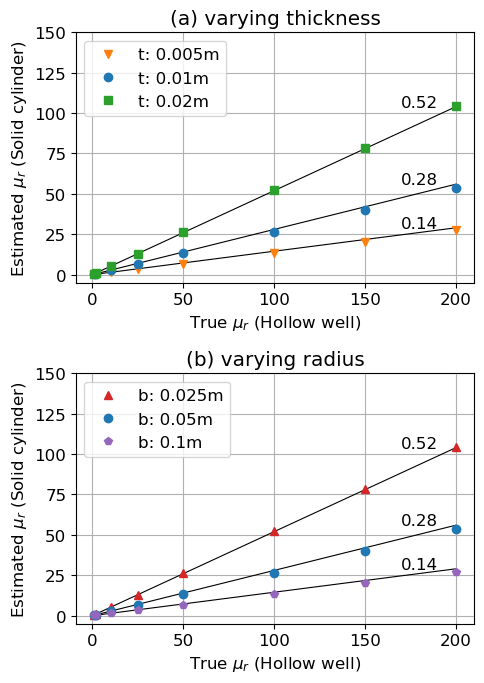

In [294]:
fig, ax = plt.subplots(2, 1, figsize=(5, 7))

markers = ["v", "o", "s"]
color_ind = [1, 0, 2]
for i, key in enumerate(mur_rec_t.keys()):
    g = geometric_factor(key, casing_b)
    ax[0].plot(mur_casing, mur_casing * g, "k", lw=0.8)
    ax[0].text(mur_casing[-1]-10, mur_casing[-1] * g , f"{g:1.2f}", ha="right")
    ax[0].plot(mur_casing, mur_rec_t[key], markers[i], color=f"C{color_ind[i]}", label=f"t: {key}m")


markers = ["^", "o", "p"]
color_ind = [3, 0, 4]
for i, key in enumerate(mur_rec_b.keys()):
    g = geometric_factor(casing_t, key)
    ax[1].plot(mur_casing, mur_casing * g, "k", lw=0.8)
    ax[1].text(mur_casing[-1]-10, mur_casing[-1] * g, f"{g:1.2f}", ha="right")
    ax[1].plot(mur_casing, mur_rec_b[key], markers[i], color=f"C{color_ind[i]}", label=f"b: {key}m")
    

for a in ax.flatten():
    # a.set_aspect(1)
    a.set_ylim([-5, 150])
    a.grid()
    a.legend()
    a.set_xlabel("True $\mu_r$ (Hollow well)")
    a.set_ylabel("Estimated $\mu_r$ (Solid cylinder)")

    
ax[0].set_title("(a) varying thickness")
ax[1].set_title("(b) varying radius")
plt.tight_layout()

In [423]:
t_vals = np.linspace(0, 2.5e-1, 2000)
b_vals = np.linspace(1e-3, 5e-1, 2000)

G = np.nan * np.ones((len(t_vals), len(b_vals)))

for i, t in enumerate(t_vals):
    b_vals_i = b_vals >= t -1e-3
    G[i, b_vals_i] = geometric_factor(t, b_vals[b_vals_i])
G[G<0] = np.nan
G[G>1] = 1.0 + 1e-12

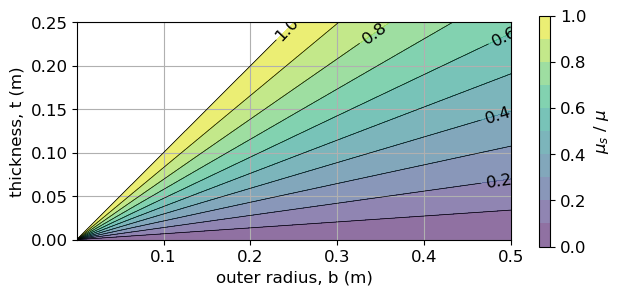

In [427]:
fig, ax = plt.subplots(1, 1, figsize=(7, 3)) 

cb = plt.colorbar(
    ax.contourf(b_vals, t_vals, G, 11, alpha=0.6, linestyles="solid", vmin=0, vmax=1),
    
)

ax.set_aspect(1)

CS = ax.contour(b_vals, t_vals, G, [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1], colors=["k"], linewidths=0.5)
ax.clabel(CS, CS.levels[1::2])

ax.grid()

ax.set_xlabel("outer radius, b (m)")
ax.set_ylabel("thickness, t (m)")
cb.set_label("$\\mu_s$ / $\\mu$")

In [74]:
inv_results = {}

def get_inv_results(inv_dict): 
    for key in inv_dict.keys:
        if key not in inv_results: 
            tmp = {}
            for freq in frequencies:
                tmp[freq] = inv_dict[key][freq].directiveList.dList[1].inversion_results
            inv_results[key] = tmp

In [75]:
tmp = inv_results[keys[0]][frequencies[0]]

In [76]:
tmp = inv_dict[keys[0]][frequencies[0]]

In [77]:
phi_d_final = {}
chifact_final = {}
phid_star = len(rx_x)*len(rx_z)*2

for key in keys:
    phid_tmp = np.ones(len(frequencies)) * np.nan
    for i, freq in enumerate(frequencies): 
        phid = inv_results[key][freq]["phi_d"]
        if len(phid) > 0: 
            phid_tmp[i] = phid[-1]
    phi_d_final[key] = phid_tmp
    chifact_final[key] = phi_d_final[key] / phid_star

In [78]:
phid_min = {}
chifact_min = {}
logsig_min = {}
mur_min = {}
rms_min = {}

for key in keys:
    phid_tmp = np.ones(len(frequencies)) * np.nan
    logsig_tmp = np.ones(len(frequencies)) * np.nan
    mur_tmp = np.ones(len(frequencies)) * np.nan
    rms_tmp = np.ones(len(frequencies)) * np.nan
    for i, freq in enumerate(frequencies): 
        phid = inv_results[key][freq]["phi_d"]
        if len(phid) > 0: 
            ind_min = np.argmin(phid)
            phid_tmp[i] = phid[ind_min]
            logsig_tmp[i] = inv_results[key][freq]["logsigma"][ind_min]
            mur_tmp[i] = inv_results[key][freq]["mur"][ind_min]
            rms_tmp[i] = inv_results[key][freq]["rms"][ind_min]
    phid_min[key] = phid_tmp
    logsig_min[key] = logsig_tmp
    mur_min[key] = mur_tmp
    rms_min[key] = rms_tmp

In [79]:
# fig, ax = plt.subplots(3, 1, figsize=(6, 12), sharex=True) 

# for key in keys: 
#     mrec = np.vstack(mrec_dict[key].values())
    
#     ax[0].semilogx(frequencies, phi_d_final[key] / phid_star, "o", label=key)
#     ax[0].semilogx(frequencies,  np.ones_like(frequencies),"--k")
#     ax[1].loglog(frequencies, np.exp(mrec[:, 0]), "o", label=key)
#     ax[1].loglog(frequencies, np.ones_like(frequencies)*sigma_casing, "--k")
#     ax[1].loglog(frequencies, np.ones_like(frequencies)*sigdc, "--k")
#     ax[2].semilogx(frequencies, mrec[:, 1], "o", label=key)

# ax[1].set_ylim([1e6, 1e8])
# # ax[0].legend()

In [80]:
# fig, ax = plt.subplots(3, 1, figsize=(6, 12), sharex=True) 

# for key in keys: 
#     ax[0].loglog(frequencies, phid_min[key], "o", label=key)
#     ax[0].semilogx(frequencies, phid_star * np.ones_like(frequencies),"--k")
#     ax[1].loglog(frequencies, np.exp(logsig_min[key]), "o", label=key)
#     ax[1].loglog(frequencies, np.ones_like(frequencies)*sigma_casing, "--k")
#     ax[1].loglog(frequencies, np.ones_like(frequencies)*sigdc, "--k")
#     ax[2].semilogx(frequencies, (mur_min[key]), "o", label=key)
# ax[0].legend()

In [129]:
markers = ["o", "v", "s", "D", "p", "^", "h", "*", "+"]

In [130]:
mur_casing

array([  1,   2,  10,  25,  50, 100, 150, 200])

In [149]:
plotkeys = np.hstack([keys[0], keys[3:]])
# plotkeys = np.hstack([keys[:2], keys[3:5], keys[6]])
# plotkeys = keys

plotkeys

array(['casing_sig5e+06_mur1', 'casing_sig5e+06_mur25',
       'casing_sig5e+06_mur50', 'casing_sig5e+06_mur100',
       'casing_sig5e+06_mur150', 'casing_sig5e+06_mur200'], dtype='<U22')

In [150]:
def mur_by_skindepth(delta):
    omega = 2 * np.pi * frequencies
    return 2 / (omega * delta**2 * sigma_casing) / mu_0

In [151]:
mur_by_skindepth(casing_t)/mu_0

array([4.03144180e+09, 2.90137090e+09, 2.08807507e+09, 1.50275771e+09,
       1.08151320e+09, 7.78349553e+08, 5.60167022e+08, 4.03144180e+08,
       2.90137090e+08, 2.08807507e+08, 1.50275771e+08, 1.08151320e+08,
       7.78349553e+07, 5.60167022e+07, 4.03144180e+07, 2.90137090e+07,
       2.08807507e+07, 1.50275771e+07, 1.08151320e+07, 7.78349553e+06,
       5.60167022e+06, 4.03144180e+06, 2.90137090e+06, 2.08807507e+06,
       1.50275771e+06, 1.08151320e+06, 7.78349553e+05, 5.60167022e+05,
       4.03144180e+05, 2.90137090e+05, 2.08807507e+05, 1.50275771e+05,
       1.08151320e+05, 7.78349553e+04, 5.60167022e+04, 4.03144180e+04])

In [152]:
# plt.plot(np.vstack(mrec_dict[keys[0]].values())[:, 0])
# plt.plot(logsig_min[keys[0]])


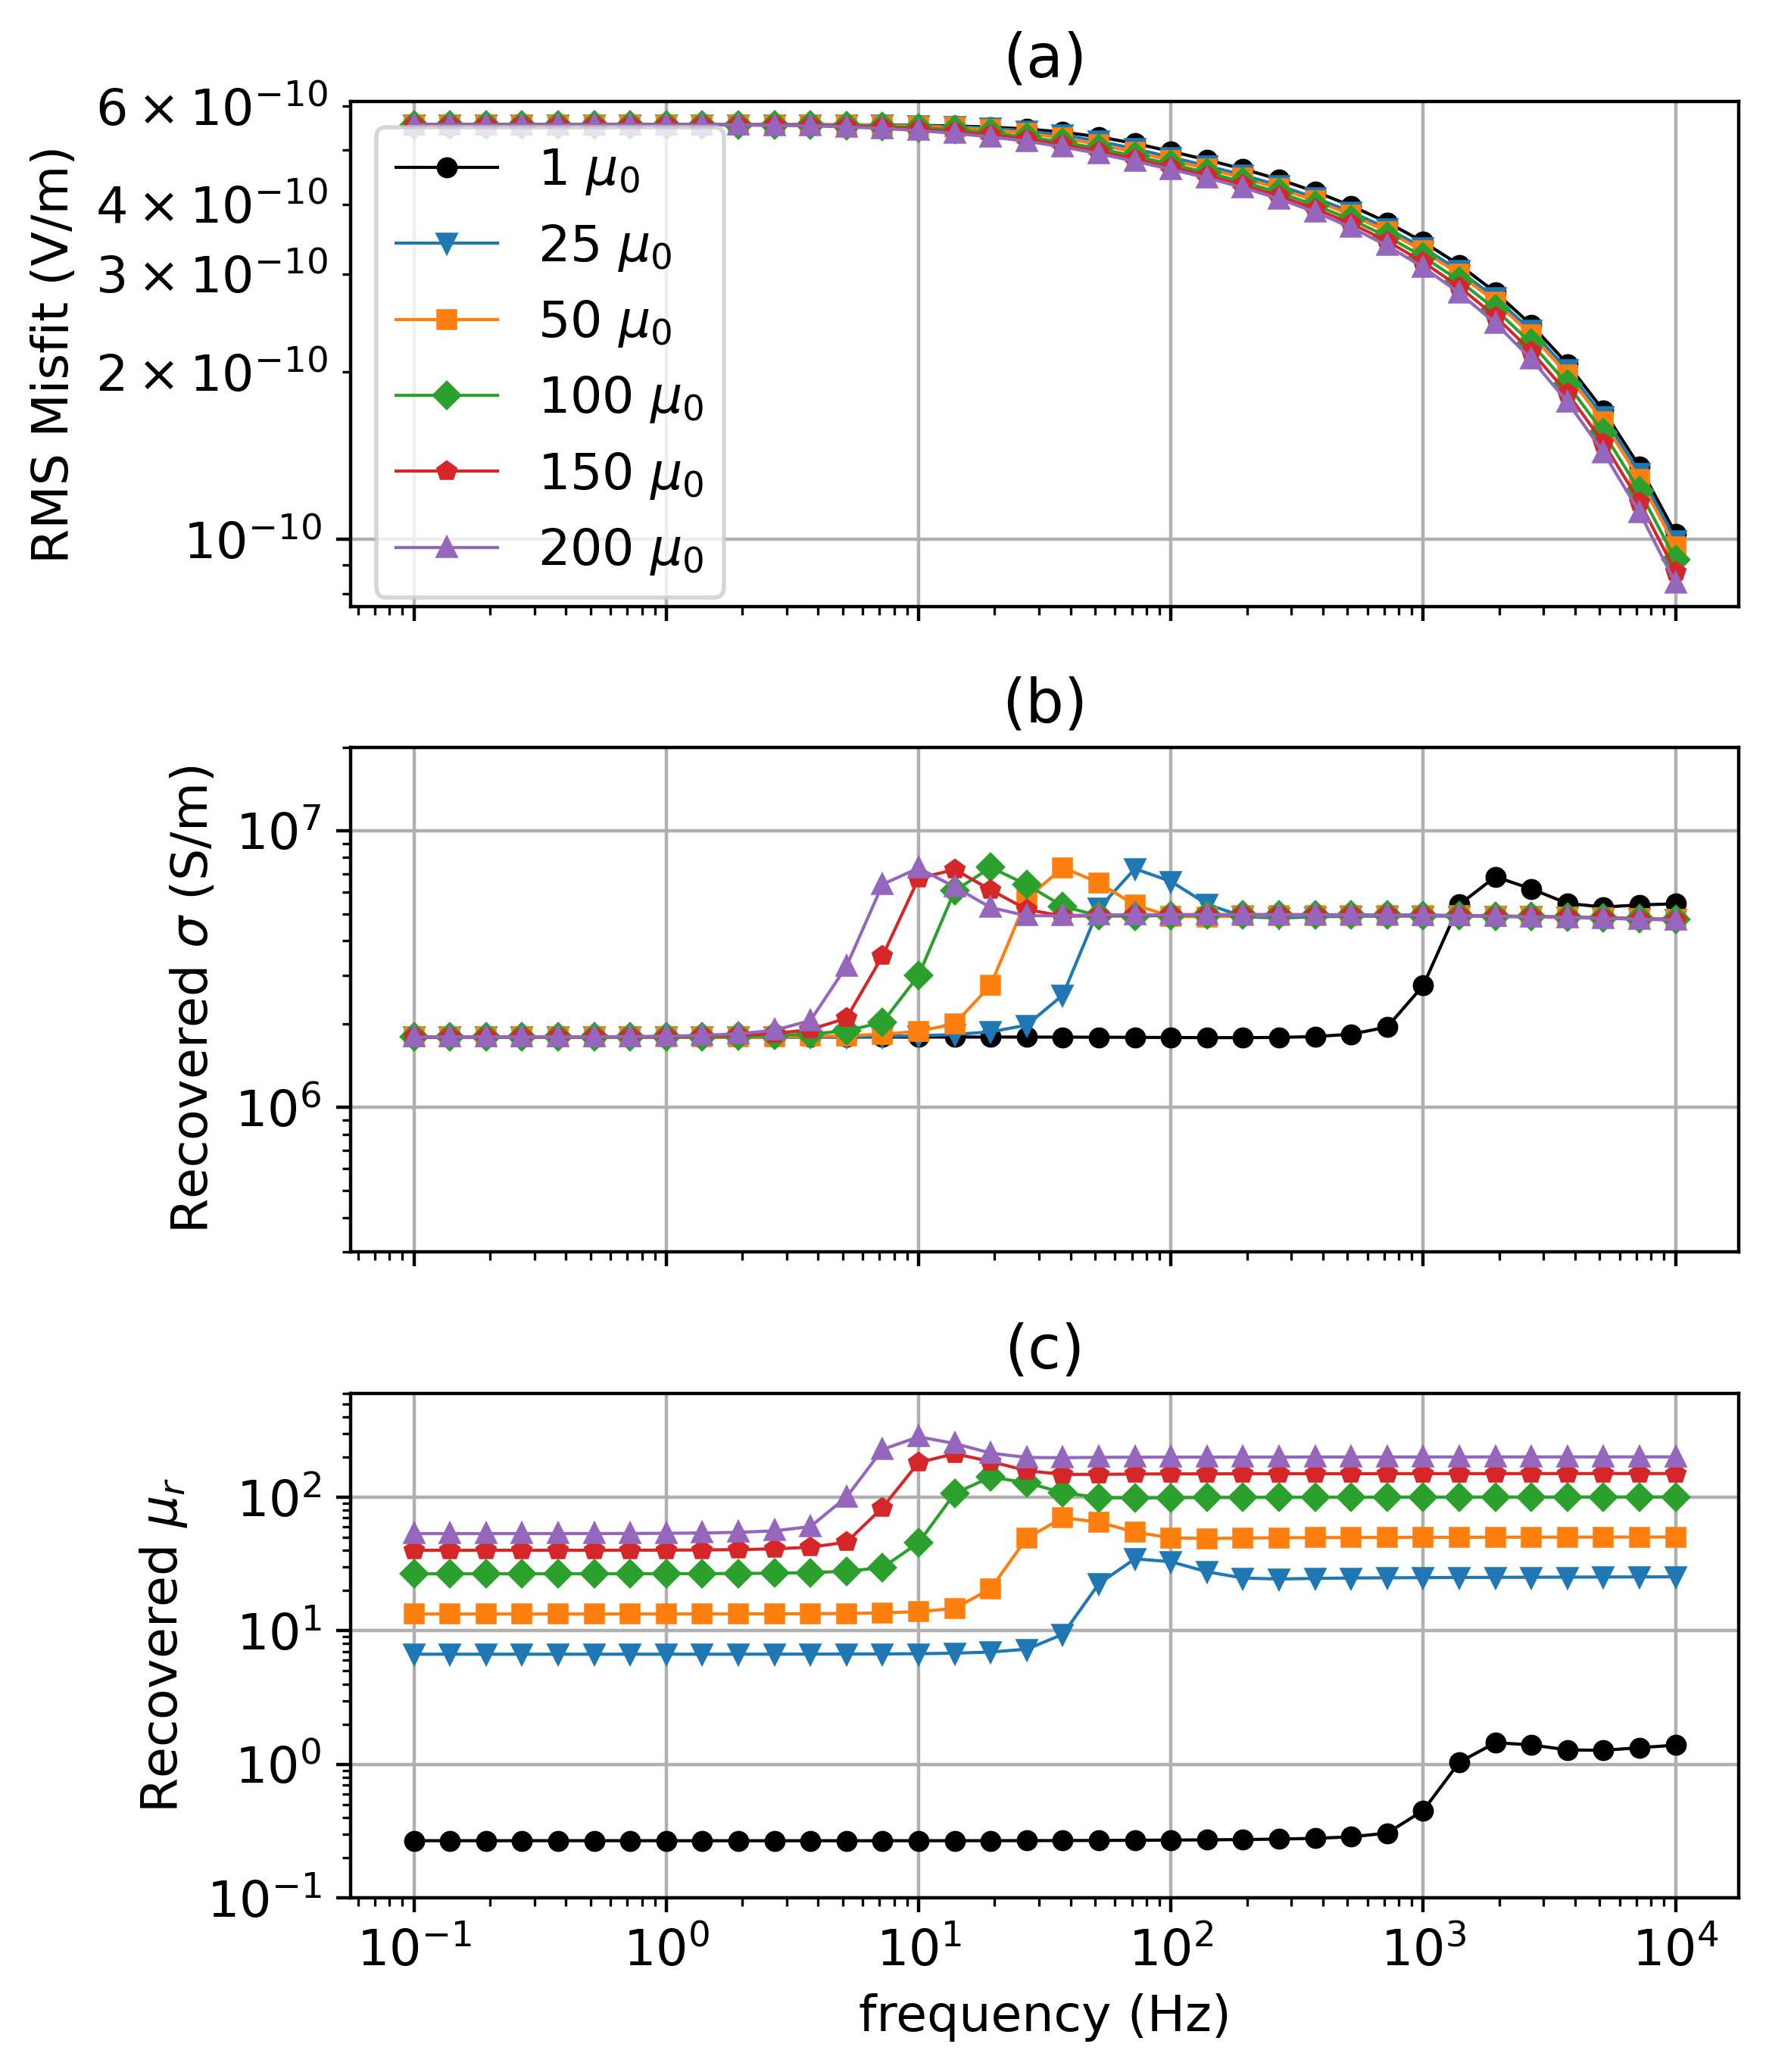

In [154]:
fig, ax = plt.subplots(3, 1, figsize=(6, 7), sharex=True, dpi=dpi_high) 

for i, key in enumerate(plotkeys): 
    color = "k" if i==0 else f"C{i-1}"
    label = f"{key.split('_')[-1][3:]} $\mu_0$"
    ax[0].loglog(frequencies, rms_min[key], f"-{markers[i]}", color=color, lw=0.75, ms=4, label=label)
    # ax[0].semilogx(frequencies, phid_star * np.ones_like(frequencies),"--k")
    ax[1].loglog(frequencies, np.exp(logsig_min[key]), f"-{markers[i]}", color=color, lw=0.75, ms=4, label=label)
    # ax[1].loglog(frequencies, np.ones_like(frequencies)*sigma_casing, "--k")
    # ax[1].loglog(frequencies, np.ones_like(frequencies)*sigdc, "--k")
    ax[2].loglog(frequencies, (mur_min[key]), f"-{markers[i]}", color=color, lw=0.75, ms=4, label=label)
    
for a in ax:
    a.grid()
    
ax[0].legend(loc=2)
ax[1].set_ylim(3e5, 2e7)
ax[2].set_ylim([0.1, 600])

# ax[2].text(1.1e3, 2, "$\delta\sim t/2$", alpha=0.7)
# ax[2].loglog(frequencies, mur_by_skindepth(casing_t/2), ":k", alpha=0.6)

# ax[2].text(2e1, 2, "$\delta\sim 1.3 t$", alpha=0.7)
# ax[2].loglog(frequencies, mur_by_skindepth(1.3*casing_t), ":k", alpha=0.6)

ax[0].set_ylabel("RMS Misfit (V/m)")
ax[1].set_ylabel("Recovered $\sigma$ (S/m)")
ax[2].set_ylabel("Recovered $\mu_r$")
ax[2].set_xlabel("frequency (Hz)")

ax[0].set_title("(a)")
ax[1].set_title("(b)")
ax[2].set_title("(c)")

plt.tight_layout()

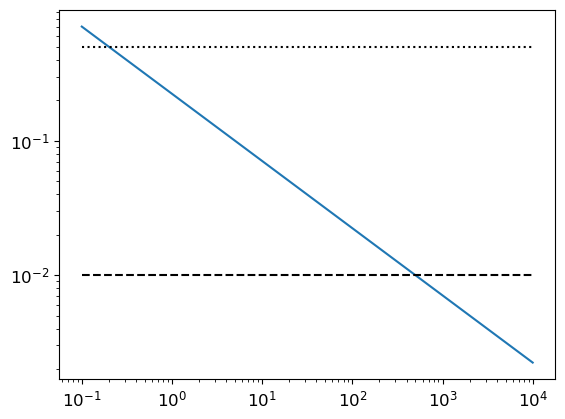

In [144]:
skin_depths_casing = 500/np.sqrt(sigma_casing * frequencies) 

fig, ax = plt.subplots(1, 1) 
ax.loglog(frequencies, skin_depths_casing)
ax.loglog(frequencies, np.ones_like(frequencies)*casing_t, "--k")
ax.loglog(frequencies, np.ones_like(frequencies)*csz, ":k")

In [145]:
from scipy import stats

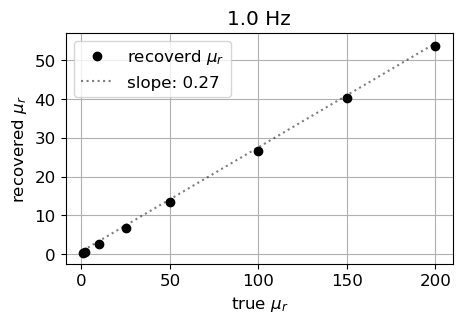

In [146]:
fig, ax = plt.subplots(1, 1, figsize=(5, 3))

freq_ind = 7

mur_1Hz =  np.array([mur_min[k][freq_ind] for k in plot_keys])
mur_true = np.array([np.float64(k.split('_')[-1][3:]) for k in plot_keys])

slope, intercept, r, p, std_err = stats.linregress(mur_true-1, mur_1Hz-1)

ax.plot(mur_true, mur_1Hz, "ko", label="recoverd $\mu_r$")
    
ax.plot(mur_true, slope*(mur_true-1)+1, ":k", alpha=0.5, label=f"slope: {slope:1.2f}")
ax.set_xlabel("true $\mu_r$")
ax.set_ylabel("recovered $\mu_r$")
ax.set_title(f"{frequencies[freq_ind]} Hz")
ax.grid("both")
# ax.set_aspect(1)
ax.legend()
    # ax.plot()

In [91]:
(slope * casing_b / casing_t)

1.3409572522369202

In [92]:
(casing_b**2 - casing_a**2)/casing_b**2 

0.3600000000000001

In [93]:
fields_rec = {}

for key in keys:
    tmp_fields = {}
    for i, freq in enumerate(frequencies):
        tmp_fields[freq] = inv_dict[key][freq].invProb.dmisfit.objfcts[0].simulation.fields(np.r_[logsig_min[key][i], mur_min[key][i]])
 
    fields_rec[key] = tmp_fields

In [94]:
def plot_fields(
    field_plot, freq_ind=0, xlim=500*np.r_[-1, 1], zlim=np.r_[-1000, 10], component="real", ax=None, vmin=None, vmax=None, aspect=True,
    plot_source=False
):
    if ax is None: 
        fig, ax = plt.subplots(1,1)

    if len(field_plot) == mesh.n_faces: 
        field_plot = mesh.average_face_to_cell_vector * np.squeeze(field_plot)
        
        out = mesh.plot_image(
            getattr(field_plot, component), "CCv", view="vec", 
            range_x = xlim, range_y = zlim,
            sample_grid = np.r_[np.diff(xlim)/100, np.diff(zlim)/100],
            mirror=True, #mirror_data=field_mirror,
            ax=ax, 
            pcolor_opts={"norm":LogNorm(vmin=vmin, vmax=vmax)},
            stream_threshold=vmin
        )

    elif len(field_plot) == mesh.n_edges: 
        field_plot = mesh.average_edge_to_cell_vector * np.squeeze(field_plot)
        
        out = mesh.plot_image(
            getattr(field_plot, component), "CC",  
            range_x = xlim, range_y = zlim,
            mirror=True, mirror_data=-1*field_plot,
            ax=ax, 
            pcolor_opts={
                "norm":SymLogNorm(linthresh=vmin if vmin is not None else 1e-12, vmin=-1*vmax if vmax is not None else None, vmax=vmax),
                "cmap":"RdBu_r",
            },
            stream_threshold=vmin
        )

    if plot_source is True: 
        ax.plot(src_locations[:, 0], src_locations[:, 2], "w", lw=2)
    
    cb = plt.colorbar(out[0], ax=ax)
    # cb.set_label("Electric Field (V/m)")
    if aspect is True:
        ax.set_aspect(1)

    return out, cb

In [95]:
x_data = mesh.nodes_x[31]
data_locs = np.hstack([mesh.faces_x[:, 0] == x_data, np.zeros(mesh.n_faces_z, dtype=bool)])
np.sum(data_locs)

1096

In [96]:
keys

['casing_sig5e+06_mur1',
 'casing_sig5e+06_mur2',
 'casing_sig5e+06_mur10',
 'casing_sig5e+06_mur25',
 'casing_sig5e+06_mur50',
 'casing_sig5e+06_mur100',
 'casing_sig5e+06_mur150',
 'casing_sig5e+06_mur200']

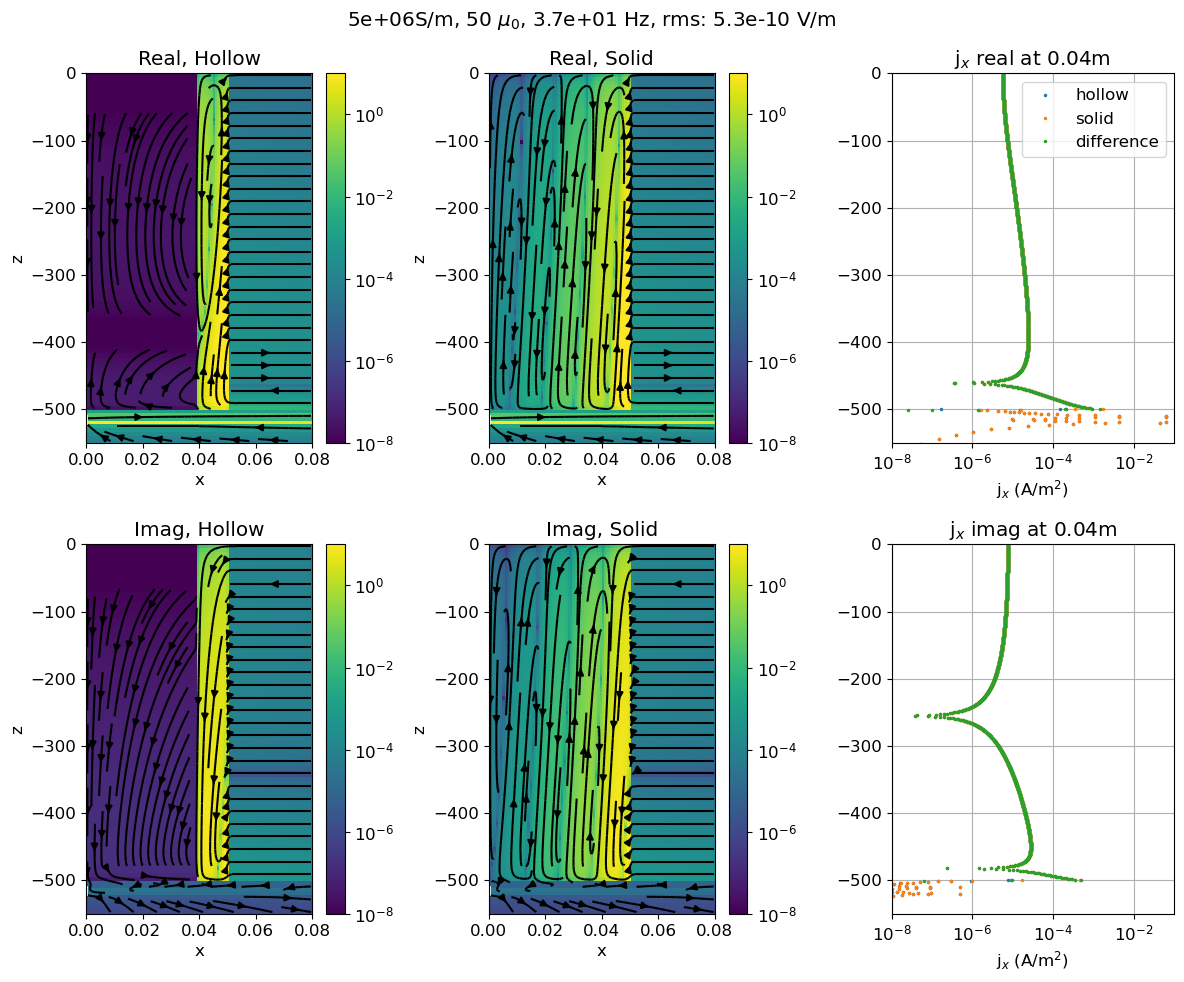

In [97]:
fig, ax = plt.subplots(2, 3, figsize=(12, 10))

key = keys[4]
freq_ind = 18

aspect = False
xlim = 0.08*np.r_[0, 1]
zlim = np.r_[-550, 0] 
plot_source = True
vmin=1e-8
vmax=1e1

true_fields = fields[key]
fields_true = true_fields[true_fields.simulation.survey.source_list[freq_ind], "j"]
plot_fields(fields_true, component="real", ax=ax[0, 0], vmin=vmin, vmax=vmax, aspect=aspect, xlim=xlim, zlim=zlim, plot_source=plot_source)
plot_fields(fields_true, component="imag", ax=ax[1, 0], vmin=vmin, vmax=vmax, aspect=aspect, xlim=xlim, zlim=zlim, plot_source=plot_source)
ax[0, 0].set_title("Real, Hollow")
ax[1, 0].set_title("Imag, Hollow")


fields_pred = fields_rec[key][frequencies[freq_ind]][:, "j"]
plot_fields(fields_pred, component="real", ax=ax[0, 1], vmin=vmin, vmax=vmax, aspect=aspect, xlim=xlim, zlim=zlim, plot_source=plot_source)
plot_fields(fields_pred, component="imag", ax=ax[1, 1], vmin=vmin, vmax=vmax, aspect=aspect, xlim=xlim, zlim=zlim, plot_source=plot_source)
ax[0, 1].set_title("Real, Solid")
ax[1, 1].set_title("Imag, Solid")

for i, component in enumerate(["real", "imag"]):
    ax[i, 2].semilogx(np.abs(getattr(fields_true[data_locs], component)), mesh.cell_centers_z, ".", ms=3, label="hollow")
    ax[i, 2].semilogx(np.abs(getattr(fields_pred[data_locs], component)), mesh.cell_centers_z, ".", ms=3, label="solid")
    ax[i, 2].semilogx(np.abs(getattr(fields_pred[data_locs] - fields_true[data_locs], component)), mesh.cell_centers_z, ".", ms=3, label="difference")
    ax[i, 2].set_ylim(zlim)
    ax[i, 2].set_xlim(np.r_[vmin, vmax*1e-2])
    ax[i, 2].grid()
    ax[i, 2].set_title(f"j$_x$ {component} at {x_data:1.2f}m")
    ax[i, 2].set_xlabel("j$_x$ (A/m$^2$)")

ax[0, 2].legend(loc=1)
fig.suptitle(f"{key.split('_')[1][3:]}S/m, {key.split('_')[-1][3:]} $\mu_0$, {frequencies[freq_ind]:1.1e} Hz, rms: {rms_min[key][freq_ind]:1.1e} V/m")

# fields_diff = fields_true - fields_pred
# plot_fields(fields_diff, component="real", ax=ax[0, 1], vmin=vmin, aspect=aspect, xlim=xlim, zlim=zlim, plot_source=plot_source)
# plot_fields(fields_diff, component="imag", ax=ax[1, 1], vmin=vmin, aspect=aspect, xlim=xlim, zlim=zlim, plot_source=plot_source)


plt.tight_layout()

In [98]:
mesh

In [99]:
src_locations

array([[   0.,    0., -510.],
       [   0.,    0., -520.]])

In [100]:
# dc response 

dc_src_list = [
    dc.sources.Dipole([], location_a=src_locations[0,:], location_b=src_locations[-1,:])
]
dc_survey = dc.Survey(dc_src_list)
dc_sim = dc.simulation.Simulation3DCellCentered(
    mesh=mesh, sigmaMap=maps.IdentityMap(mesh),
    survey=dc_survey, solver=Pardiso, bc_type="Dirichlet",
#     verbose=True
)

In [101]:
hollow_wells = {}
solid_wells = {}

for i, key in enumerate(keys): 
    sig_solid = np.exp(logsig_min[keys[i]][0])
    mur_solid = mur_min[keys[i]][0]
    
    hollow_well = get_physical_property_model(
        mesh, casing_a, casing_b, casing_l, sigma_back=sigma_back, sigma_casing=sigma_casing, sigma_air=1e-4, mur_casing=mur_casing[i]
    )
    hollow_wells[key] = {
        "sigma": hollow_well[0],
        "mur": hollow_well[1]
    }
    
    solid_well = get_physical_property_model(
        mesh, 0, casing_b, casing_l, sigma_back=sigma_back, sigma_casing=sig_solid, sigma_air=1e-4, mur_casing=mur_solid
    )

    solid_wells[key] = {
        "sigma": solid_well[0],
        "mur": solid_well[1]
    }

In [102]:
dc_fields_hollow = dc_sim.fields(models[keys[key_ind]]["sigma"])
dc_fields_solid = dc_sim.fields(solid_wells[keys[0]]["sigma"])

In [103]:
def getAmmr(mur):
    vol = mesh.cell_volumes
    Div = discretize.utils.sdiag(vol) * mesh.face_divergence
    MeMuI = mesh.get_edge_inner_product(mur * mu_0, invert_matrix=True)
    mui = 1./(mur*mu_0)
    return (
        mesh.edge_curl
        * MeMuI
        * mesh.edge_curl.T.tocsr()
        - Div.T.tocsr()
        * discretize.utils.sdiag(1.0 / vol * mui)
        * Div  # stabalizing term. See (Chen, Haber & Oldenburg 2002)
    )

In [104]:
dc_src = dc_src_list[0]

In [105]:
js_dc = line_through_faces(
    mesh, dc_src.location, normalize_by_area=True
)

In [106]:
def solve_mmr(mur, dc_fields):
    Ammr = getAmmr(mur)
    Ammr_inv = Pardiso(Ammr)
    rhs = js_dc + dc_fields[:, "j"].flatten()
    mmr_a = Ammr_inv * rhs
    
    MeMuI = mesh.get_edge_inner_product(mur * mu_0, invert_matrix=True)
    b_mmr = mesh.edge_curl.T * mmr_a
    h_mmr = MeMuI * b_mmr

    return {
        "a": mmr_a, 
        "b": b_mmr, 
        "h": h_mmr
    }


    

In [107]:
mmr_hollow = {}
mmr_solid = {}

for key in keys:
    mmr_hollow[key] = solve_mmr(hollow_wells[key]["mur"], dc_fields_hollow)
    mmr_solid[key] = solve_mmr(solid_wells[key]["mur"], dc_fields_solid)
    

In [108]:
plot_inds = mesh.edges[:, 0] == mesh.nodes_x[np.argmin(np.abs(mesh.nodes_x - casing_b)) - 1]

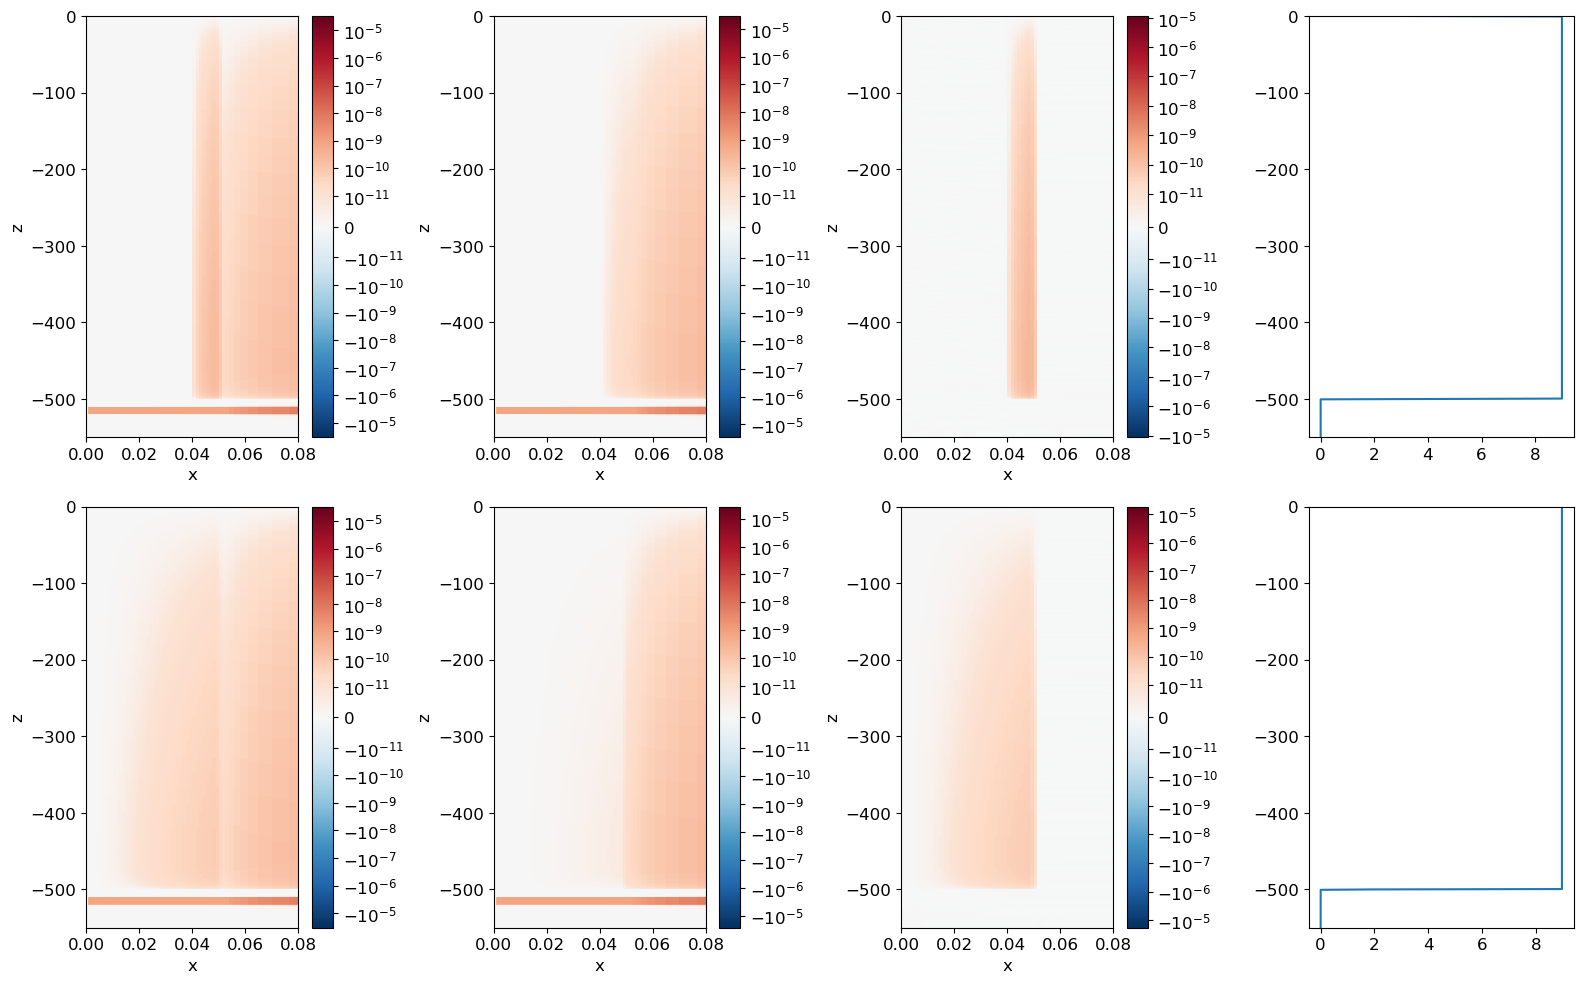

In [109]:
fig, ax = plt.subplots(2, 4, figsize=(16, 10))

key = keys[2]

aspect = False
xlim = 0.08*np.r_[0, 1]
zlim = np.r_[-550, 0] 
plot_source = True
vmin=1e-11
# vmax=1e1

for j, solution in enumerate([mmr_hollow, mmr_solid]): 
    plot_fields(solution[key]["b"], component="real", ax=ax[j, 0], vmin=vmin, vmax=None, aspect=aspect, xlim=xlim, zlim=zlim, plot_source=plot_source) 
    plot_fields(solution[keys[0]]["b"], component="real", ax=ax[j, 1], vmin=vmin, vmax=None, aspect=aspect, xlim=xlim, zlim=zlim, plot_source=plot_source)
    plot_fields(solution[key]["b"] - solution[keys[0]]["b"], component="real", ax=ax[j, 2], vmin=vmin, vmax=None, aspect=aspect, xlim=xlim, zlim=zlim, plot_source=plot_source)
    
    ax[j, 3].plot(((solution[key]["b"] - solution[keys[0]]["b"])/solution[keys[0]]["b"])[plot_inds], mesh.nodes_z)
    ax[j, 3].set_ylim(zlim)

# fields_pred = fields_rec[key][frequencies[freq_ind]][:, "j"]
# plot_fields(fields_pred, component="real", ax=ax[0, 1], vmin=vmin, vmax=vmax, aspect=aspect, xlim=xlim, zlim=zlim, plot_source=plot_source)
# plot_fields(fields_pred, component="imag", ax=ax[1, 1], vmin=vmin, vmax=vmax, aspect=aspect, xlim=xlim, zlim=zlim, plot_source=plot_source)
# ax[0, 1].set_title("Real, Solid")
# ax[1, 1].set_title("Imag, Solid")


plt.tight_layout()

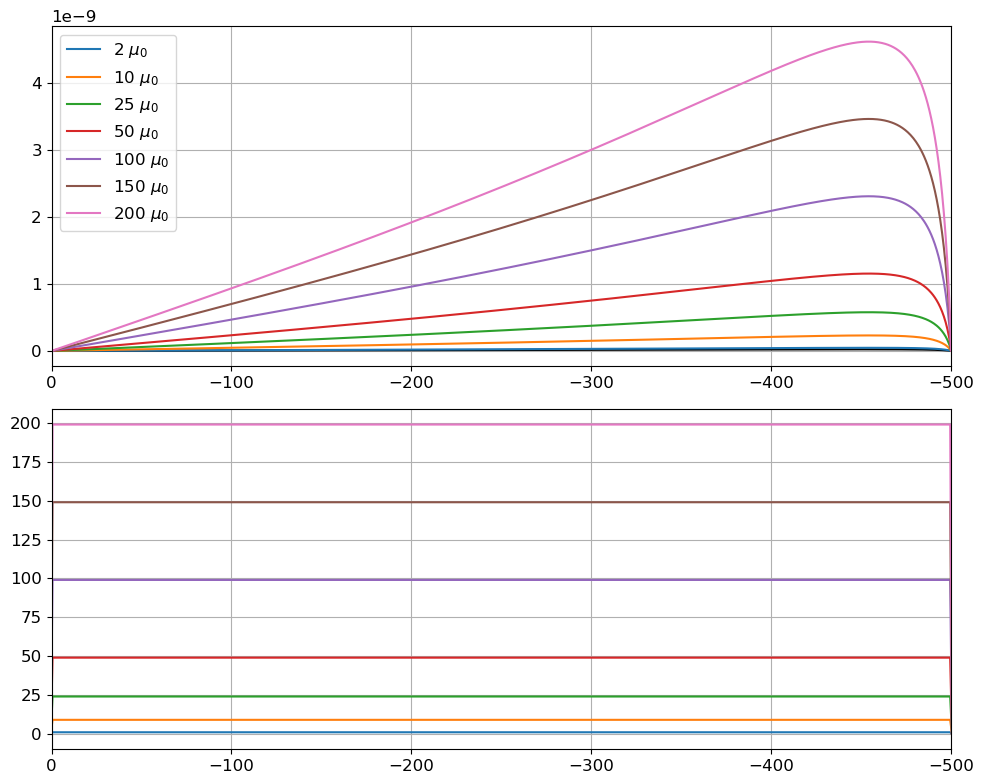

In [110]:
fig, ax = plt.subplots(2, 1, figsize=(10, 8))

xlim = np.r_[0, -casing_l]

solution = mmr_hollow

ax[0].plot(mesh.nodes_z, solution[keys[0]]["b"][plot_inds], color="k")

for i, key in enumerate(keys[1:]):
    ax[0].plot(mesh.nodes_z, solution[key]["b"][plot_inds], label=f"{key.split('_')[2][3:]} $\mu_0$", color=f"C{i}")
    # ax[0].plot(mesh.nodes_z, mur_casing[i+1]*b_mmr[keys[0]][plot_inds], label=f"{key.split('_')[2][3:]} $\mu_0$", color=f"C{i}", ls="--")
    ax[1].plot(mesh.nodes_z, ((solution[key]["b"]-solution[keys[0]]["b"])/solution[keys[0]]["b"])[plot_inds], label=key)

ax[0].legend()
for a in ax:
    a.set_xlim(xlim)
    a.grid()
# ax[0].set_ylim(-1e-8, 3e-8)
plt.tight_layout()

In [111]:
mur_static = np.array([mur_min[k][0] for k in keys])
mur_static

array([ 0.26772322,  0.53450278,  2.66972868,  6.67328081, 13.34590153,
       26.69134529, 40.03737101, 53.38429898])

In [112]:
mur_casing/mur_static

array([3.73520079, 3.74179534, 3.74569898, 3.74628323, 3.74646852,
       3.74653278, 3.74649974, 3.7464199 ])

In [113]:
1 - casing_a**2 / casing_b**2

0.3600000000000001

In [114]:
(mur_casing - 1)/(mur_static - 1)

array([-0.        , -2.14824053,  5.39009727,  4.23035644,  3.96892846,
        3.85343776,  3.81685539,  3.7988482 ])

In [115]:
for i, key in enumerate(keys[1:]):  
    hollow_sol = ((mmr_hollow[key]["b"]-mmr_hollow[keys[0]]["b"])/mmr_hollow[keys[0]]["b"])[plot_inds]
    solid_sol = ((mmr_solid[key]["b"]-mmr_solid[keys[0]]["b"])/mmr_solid[keys[0]]["b"])[plot_inds]
    print(f"{key:25s}: {hollow_sol.max():6.2f}, {solid_sol.max():6.2f}, {hollow_sol.max()/solid_sol.max():6.2f}")

casing_sig5e+06_mur2     :   1.00,   1.00,   1.00
casing_sig5e+06_mur10    :   9.00,   8.97,   1.00
casing_sig5e+06_mur25    :  24.00,  23.93,   1.00
casing_sig5e+06_mur50    :  49.00,  48.85,   1.00
casing_sig5e+06_mur100   :  99.00,  98.70,   1.00
casing_sig5e+06_mur150   : 149.00, 148.55,   1.00
casing_sig5e+06_mur200   : 199.00, 198.40,   1.00


In [116]:
for i, key in enumerate(keys[1:]):  
    hollow_sol = (mmr_hollow[key]["b"])[plot_inds]
    solid_sol = (mmr_solid[key]["b"])[plot_inds]
    print(f"{key:25s}: {hollow_sol.max():1.2e}, {solid_sol.max():1.2e}, {hollow_sol.max()/solid_sol.max():6.2f}")

casing_sig5e+06_mur2     : 7.85e-10, 7.85e-10,   1.00
casing_sig5e+06_mur10    : 7.85e-10, 7.85e-10,   1.00
casing_sig5e+06_mur25    : 7.85e-10, 7.85e-10,   1.00
casing_sig5e+06_mur50    : 1.16e-09, 7.85e-10,   1.47
casing_sig5e+06_mur100   : 2.31e-09, 7.85e-10,   2.94
casing_sig5e+06_mur150   : 3.47e-09, 1.02e-09,   3.40
casing_sig5e+06_mur200   : 4.63e-09, 1.36e-09,   3.40


In [117]:
plot_inds = mesh.edges[:, 2] == mesh.nodes_z[np.argmin(np.abs(mesh.nodes_z - -400))]

(0.0, 0.2)

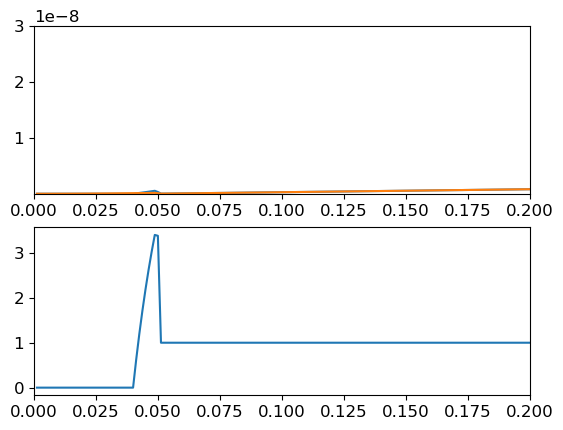

In [118]:
fig, ax = plt.subplots(2, 1) 
key = keys[3]
ax[0].plot(mesh.nodes_x, mmr_hollow[key]["b"][plot_inds])
ax[0].plot(mesh.nodes_x, mmr_solid[key]["b"][plot_inds])
ax[0].set_xlim([0, 0.2])
ax[0].set_ylim(np.r_[1e-11, 3e-8])

ax[1].plot(mesh.nodes_x, mmr_hollow[key]["b"][plot_inds]/mmr_solid[key]["b"][plot_inds])
ax[1].set_xlim([0, 0.2])

In [119]:
casing_b / casing_t

5.0

(0.0, 0.2)

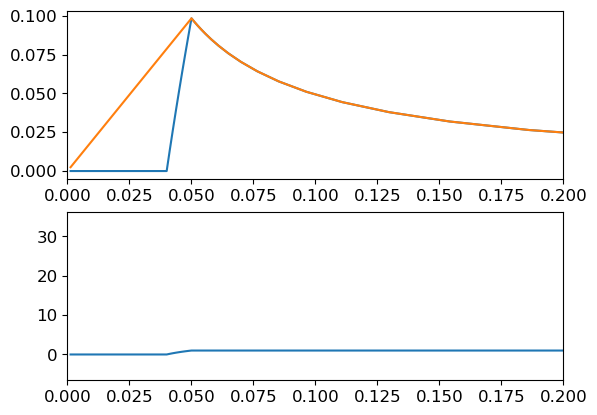

In [120]:
fig, ax = plt.subplots(2, 1) 
key = keys[4]
ax[0].plot(mesh.nodes_x, mmr_hollow[key]["h"][plot_inds])
ax[0].plot(mesh.nodes_x, mmr_solid[key]["h"][plot_inds])
ax[0].set_xlim([0, 0.2])
# ax[0].set_ylim(np.r_[1e-11, 3e-8])

ax[1].plot(mesh.nodes_x, mmr_hollow[key]["h"][plot_inds]/mmr_solid[key]["h"][plot_inds])
ax[1].set_xlim([0, 0.2])

In [121]:
mmr_hollow[key]["h"][plot_inds].max()

0.09836150730892383

In [122]:

max_b_hollow = mmr_hollow[key]["b"][(plot_inds & (mesh.edges[:, 0] <= casing_b))].max()
max_b_solid = mmr_solid[key]["b"][(plot_inds & (mesh.edges[:, 0] <= casing_b))].max()

max_b_hollow, max_b_solid

(1.0470534248928754e-09, 3.079629630574719e-10)

In [123]:
hollow_max_j * np.pi * (casing_b**2 - casing_a**2)

NameError: name 'hollow_max_j' is not defined

In [ ]:
key

In [ ]:
integrate_inds = plot_inds & mesh.edges[:, 0] <= casing_b

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(8, 5))

key = keys[4]

aspect = False
xlim = 0.08*np.r_[0, 1]
zlim = np.r_[-550, 0] 
plot_source = True
vmin=1e-11
# vmax=1e1

plot_fields(dc_fields_hollow[:, "j"], component="real", ax=ax[0], vmin=vmin, vmax=None, aspect=aspect, xlim=xlim, zlim=zlim, plot_source=plot_source) 
plot_fields(dc_fields_solid[:, "j"], component="real", ax=ax[1], vmin=vmin, vmax=None, aspect=aspect, xlim=xlim, zlim=zlim, plot_source=plot_source)
    
# fields_pred = fields_rec[key][frequencies[freq_ind]][:, "j"]
# plot_fields(fields_pred, component="real", ax=ax[0, 1], vmin=vmin, vmax=vmax, aspect=aspect, xlim=xlim, zlim=zlim, plot_source=plot_source)
# plot_fields(fields_pred, component="imag", ax=ax[1, 1], vmin=vmin, vmax=vmax, aspect=aspect, xlim=xlim, zlim=zlim, plot_source=plot_source)
# ax[0, 1].set_title("Real, Solid")
# ax[1, 1].set_title("Imag, Solid")


plt.tight_layout()

In [ ]:
dc_fields_hollow[:, "j"][mesh.n_faces_x:].shape

In [ ]:
mesh.n_faces_z

In [ ]:
plot_inds_j = mesh.faces_z[:, 2] == mesh.nodes_z[np.argmin(np.abs(mesh.nodes_z - -400))]

In [ ]:
fig, ax = plt.subplots(1, 1)
ax.plot(mesh.cell_centers_x, dc_fields_hollow[:, "j"][mesh.n_faces_x:][plot_inds_j])
ax.plot(mesh.cell_centers_x, dc_fields_solid[:, "j"][mesh.n_faces_x:][plot_inds_j])
ax.set_xlim(np.r_[0, 0.1])

In [ ]:
hollow_max_j = dc_fields_hollow[:, "j"][mesh.n_faces_x:][plot_inds_j].max()
solid_max_j = dc_fields_solid[:, "j"][mesh.n_faces_x:][plot_inds_j].max()
hollow_max_j, solid_max_j, hollow_max_j / solid_max_j

In [ ]:
hollow_max_j * (casing_b**2 - casing_a**2)/casing_b**2

In [ ]:
hollow_max_j * np.pi * (casing_b**2 - casing_a**2)

In [ ]:
solid_max_j * np.pi * casing_b**2

In [ ]:
fig, ax = plt.subplots(1, 4, figsize=(16, 5))

key = keys[2]

aspect = False
xlim = 0.08*np.r_[0, 1]
zlim = np.r_[-550, 0] 
plot_source = True
vmin=1e-14
# vmax=1e1

# plot_fields(dc_fields[:, "j"], component="real", ax=ax[0], vmin=vmin, vmax=vmax, aspect=aspect, xlim=xlim, zlim=zlim, plot_source=plot_source)

plot_fields(h_mmr[key], component="real", ax=ax[0], vmin=vmin, vmax=None, aspect=aspect, xlim=xlim, zlim=zlim, plot_source=plot_source) 
plot_fields(h_mmr[keys[0]], component="real", ax=ax[1], vmin=vmin, vmax=None, aspect=aspect, xlim=xlim, zlim=zlim, plot_source=plot_source)
plot_fields(h_mmr[key] - h_mmr[keys[0]], component="real", ax=ax[2], vmin=vmin, vmax=None, aspect=aspect, xlim=xlim, zlim=zlim, plot_source=plot_source)

ax[3].plot(((h_mmr[key] - h_mmr[keys[0]])/h_mmr[keys[0]])[plot_inds], mesh.nodes_z)
ax[3].set_ylim(zlim)

# fields_pred = fields_rec[key][frequencies[freq_ind]][:, "j"]
# plot_fields(fields_pred, component="real", ax=ax[0, 1], vmin=vmin, vmax=vmax, aspect=aspect, xlim=xlim, zlim=zlim, plot_source=plot_source)
# plot_fields(fields_pred, component="imag", ax=ax[1, 1], vmin=vmin, vmax=vmax, aspect=aspect, xlim=xlim, zlim=zlim, plot_source=plot_source)
# ax[0, 1].set_title("Real, Solid")
# ax[1, 1].set_title("Imag, Solid")


plt.tight_layout()

In [ ]:
np.max(np.abs(h_mmr[key] - h_mmr[keys[0]]))

In [ ]:
mesh.n_cells

In [ ]:
mesh.n_cells*2